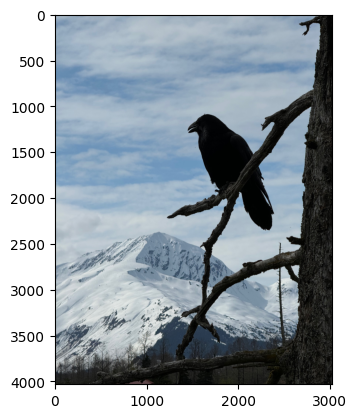

11

<Figure size 640x480 with 0 Axes>

In [1]:
import matplotlib.pyplot as plt
import PIL.Image as Image

img = Image.open("../data/p1ch02/bird.jpeg")
plt.imshow(img)
plt.show()
def onclick(event):
    print(f"x={event.xdata:.0f}, y={event.ydata:.0f}")
plt.connect('button_press_event', onclick)

/opt/anaconda3/envs/pytorch-2e-py311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 314/314 [00:00<00:00, 22114.20it/s]
The image processor of type `SamImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


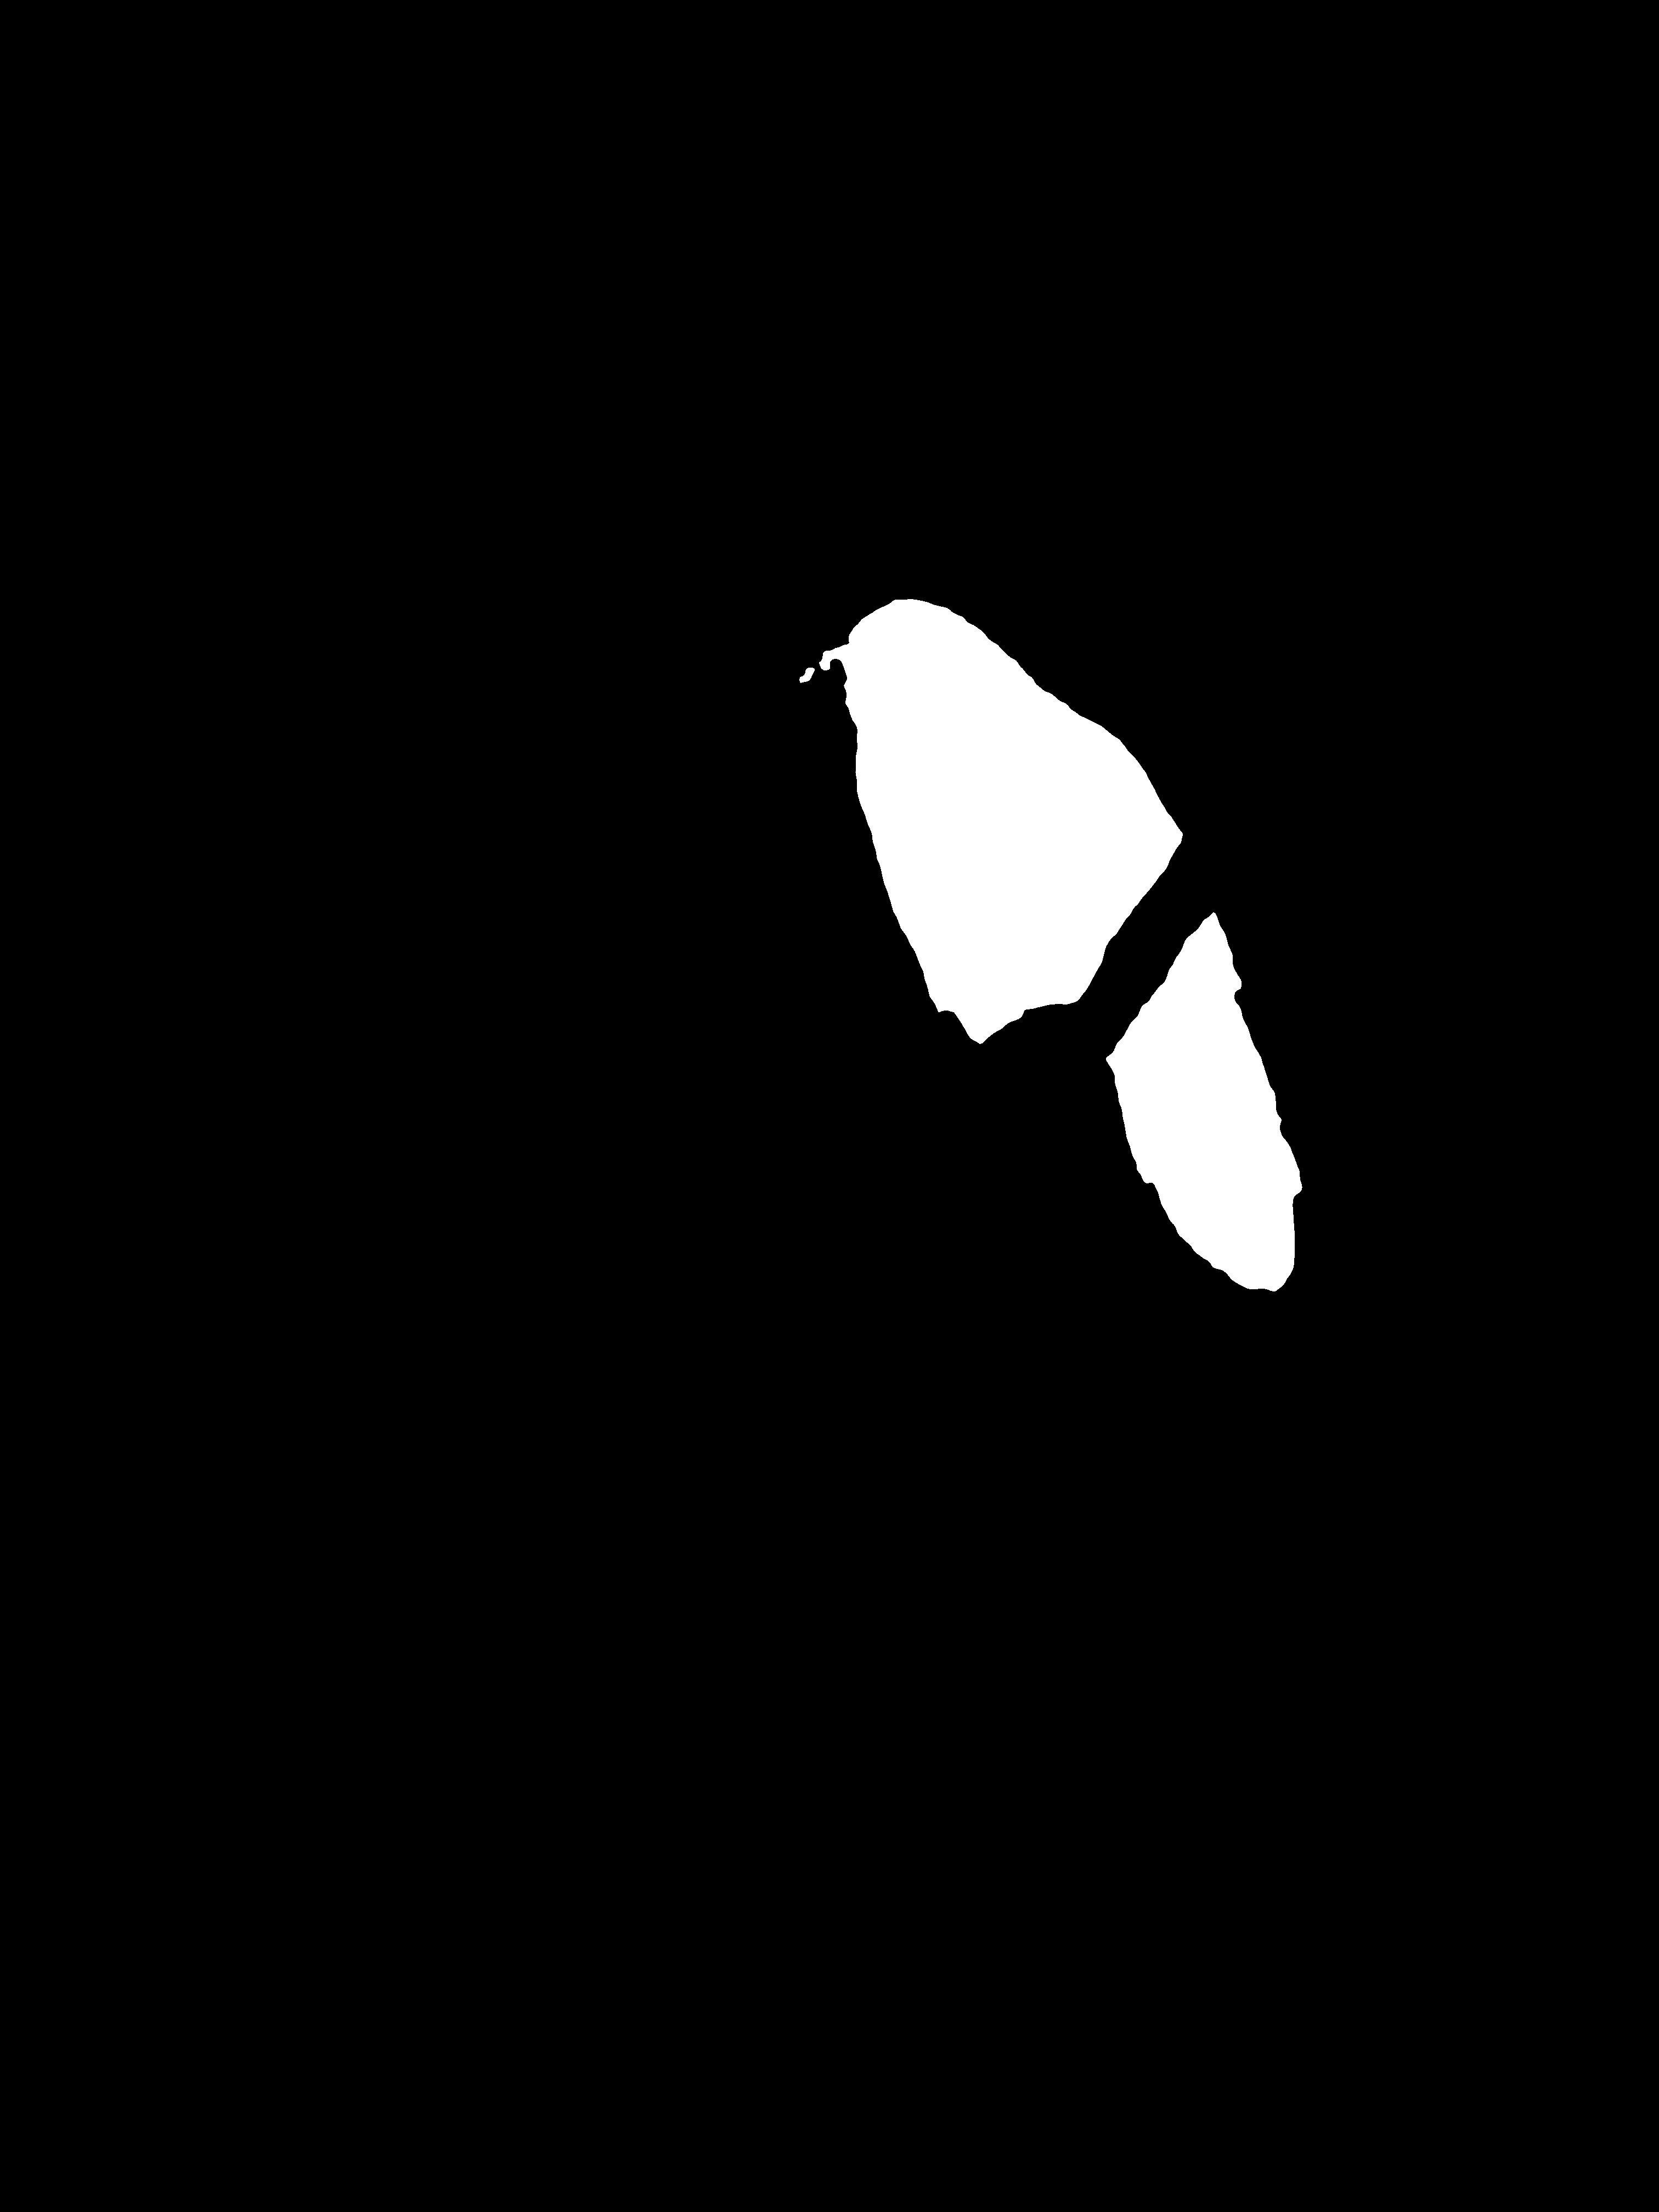

In [2]:
from PIL import Image
import requests
from transformers import SamModel, SamProcessor
import torch
import numpy as np

device = "cpu"
model = SamModel.from_pretrained("facebook/sam-vit-base").to(device)
processor = SamProcessor.from_pretrained("facebook/sam-vit-base")

raw_img = Image.open("../data/p1ch02/bird.jpeg")
input_points = [[[2000, 1500]]] # 2D localization of a bear

inputs = processor(raw_img, input_points=input_points, return_tensors="pt").to(device)
with torch.no_grad():
    outputs = model(**inputs)
mask = processor.image_processor.post_process_masks(
    outputs.pred_masks.cpu(),
    inputs["original_sizes"].cpu(),
    inputs["reshaped_input_sizes"].cpu()
)[0][0][1].numpy()
Image.fromarray(mask).save("../data/p1ch02/bird_mask.jpg")
Image.fromarray(mask)

In [ ]:
from transformers import pipeline
import os
os.environ["HF_TOKEN"] = "XXX"
raw_image = Image.open("../data/p1ch02/moose.jpeg")
resized_raw_image = raw_image.resize((1024, 1024))
print(resized_raw_image.size)
generator =  pipeline("mask-generation", device = "mps", points_per_batch = 256)
outputs = generator(resized_raw_image, points_per_batch = 256)

No model was supplied, defaulted to facebook/sam-vit-huge and revision 87aecf0.
Using a pipeline without specifying a model name and revision in production is not recommended.


(1024, 1024)


Loading weights: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 594/594 [00:00<00:00, 8007.90it/s]


/var/folders/bs/9j5t349d48g3lctd8l3l5l1r0000gn/T/ipykernel_62149/627311796.py:7: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)


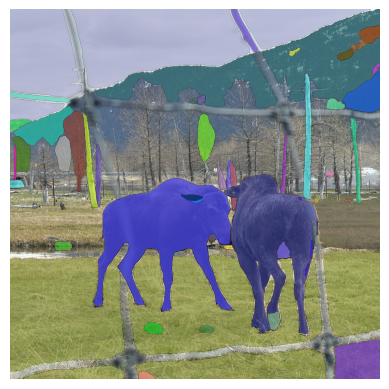

In [8]:
def show_mask(mask, ax, random_color=False):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([30 / 255, 144 / 255, 255 / 255, 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)
    

plt.imshow(np.array(resized_raw_image))
ax = plt.gca()
for mask in outputs["masks"]:
    show_mask(mask, ax=ax, random_color=True)
plt.axis("off")
plt.show()